In [1]:
import os
import sys

# --- Fix: protobuf import crash in Kaggle TF/Keras stacks.
# Use the supported env vars (python impl + disable C descriptors) BEFORE any TF/Keras/protobuf import.
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION"] = "2"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_USE_C_DESCRIPTORS"] = "0"

# If protobuf was partially imported earlier in this kernel, remove it so env vars take effect deterministically.
for m in list(sys.modules.keys()):
    if m.startswith("google.protobuf"):
        sys.modules.pop(m, None)

import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

KERAS_BACKEND = "tf_keras"
try:
    import tf_keras as keras
    from tf_keras.models import Sequential
    from tf_keras.layers import Dense, Dropout, BatchNormalization, LSTM
    from tf_keras import optimizers
    from tf_keras import regularizers
    from tf_keras import backend
except Exception as e:
    KERAS_BACKEND = "tensorflow.keras"
    import tensorflow as tf  # noqa: F401
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LSTM
    from tensorflow.keras import optimizers
    from tensorflow.keras import regularizers
    from tensorflow.keras import backend

    print("tf_keras import failed; fell back to tensorflow.keras. Error was:", repr(e))

TRAIN_PATH = "/kaggle/input/new-york-city-taxi-fare-prediction/labels.csv"
TEST_PATH = "/kaggle/input/new-york-city-taxi-fare-prediction/test.csv"
SUBMISSION_NAME = "submissiontry_water.csv"

BATCH_SIZE = 256
EPOCHS = 50
LEARNING_RATE = 0.001
DATASET_SIZE = 80000

np.random.seed(1)
print("Keras backend    :", KERAS_BACKEND)
print("Using TRAIN_PATH :", TRAIN_PATH, "exists:", os.path.exists(TRAIN_PATH))
print("Using TEST_PATH  :", TEST_PATH, "exists:", os.path.exists(TEST_PATH))
print("Will write       :", SUBMISSION_NAME)



2026-01-19 12:34:09.977776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768826049.990643      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768826049.994512      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-19 12:34:10.009210: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Keras backend    : tf_keras
Using TRAIN_PATH : /kaggle/input/new-york-city-taxi-fare-prediction/labels.csv exists: True
Using TEST_PATH  : /kaggle/input/new-york-city-taxi-fare-prediction/test.csv exists: True
Will write       : submissiontry_water.csv


In [2]:
import urllib.request
from PIL import Image


def remove_datapoints_from_water(df):
    """
    If a local NYC mask image exists in the working directory, filter rides whose pickup/dropoff are on land.
    If not available (typical Kaggle no-internet setting), return df unchanged.
    """

    def lonlat_to_xy(longitude, latitude, dx, dy, BB):
        x = (dx * (longitude - BB[0]) / (BB[1] - BB[0])).astype("int")
        y = (dy - dy * (latitude - BB[2]) / (BB[3] - BB[2])).astype("int")
        return x, y

    BB = (-74.5, -72.8, 40.5, 41.8)
    local_mask_candidates = [
        "nyc_mask-74.5_-72.8_40.5_41.8.png",
        "/kaggle/working/nyc_mask-74.5_-72.8_40.5_41.8.png",
        "/kaggle/input/nyc_mask-74.5_-72.8_40.5_41.8.png",
    ]
    mask_path = next((p for p in local_mask_candidates if os.path.exists(p)), None)

    if mask_path is None:
        return df

    nyc_mask = plt.imread(mask_path)
    if nyc_mask.ndim == 3:
        nyc_mask = nyc_mask[:, :, 0]
    nyc_mask = nyc_mask > 0.9

    pickup_x, pickup_y = lonlat_to_xy(
        df.pickup_longitude.values,
        df.pickup_latitude.values,
        nyc_mask.shape[1],
        nyc_mask.shape[0],
        BB,
    )
    dropoff_x, dropoff_y = lonlat_to_xy(
        df.dropoff_longitude.values,
        df.dropoff_latitude.values,
        nyc_mask.shape[1],
        nyc_mask.shape[0],
        BB,
    )

    pickup_x = np.clip(pickup_x, 0, nyc_mask.shape[1] - 1)
    dropoff_x = np.clip(dropoff_x, 0, nyc_mask.shape[1] - 1)
    pickup_y = np.clip(pickup_y, 0, nyc_mask.shape[0] - 1)
    dropoff_y = np.clip(dropoff_y, 0, nyc_mask.shape[0] - 1)

    idx = nyc_mask[pickup_y, pickup_x] & nyc_mask[dropoff_y, dropoff_x]
    return df[idx]


def clean(df):
    print(" Old size: %d" % len(df))
    df = df.dropna(how="any", axis="rows")
    print(" New size after dropna: %d" % len(df))

    df = df[
        (df["dropoff_longitude"] != df["pickup_longitude"])
        & (df["dropoff_latitude"] != df["pickup_latitude"])
    ]
    print(" New size after removing same long lat: %d" % len(df))

    df = df[
        (df["dropoff_longitude"] != 0)
        & (df["pickup_longitude"] != 0)
        & (df["dropoff_latitude"] != 0)
        & (df["pickup_latitude"] != 0)
    ]
    print(" New size after removing 0 long lat: %d" % len(df))

    MinMax = (-74.5, -72.8, 40.5, 41.8)
    df = df[
        (MinMax[0] <= df["pickup_longitude"]) & (df["pickup_longitude"] <= MinMax[1])
    ]
    df = df[
        (MinMax[0] <= df["dropoff_longitude"]) & (df["dropoff_longitude"] <= MinMax[1])
    ]
    df = df[(MinMax[2] <= df["pickup_latitude"]) & (df["pickup_latitude"] <= MinMax[3])]
    df = df[
        (MinMax[2] <= df["dropoff_latitude"]) & (df["dropoff_latitude"] <= MinMax[3])
    ]
    print(" New size after NYC lang lot: %d" % len(df))

    df = df[((df["pickup_latitude"] - df["dropoff_latitude"]).abs() > 0.001)]
    df = df[((df["pickup_longitude"] - df["dropoff_longitude"]).abs() > 0.001)]
    print(" New size after lang - lot > 0.001: %d" % len(df))

    if "fare_amount" in df.columns:
        df = df[(0 < df["fare_amount"]) & (df["fare_amount"] <= 50)]
        print(" New size after removing outliers: %d" % len(df))

    df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]
    print(" New size after removing 6=>passenger_count > 0 : %d" % len(df))

    nyc_coord = (40.7141667, -74.0063889)
    fk_coord = (40.639722, -73.778889)
    ewr_coord = (40.6925, -74.168611)
    lga_coord = (40.77725, -73.872611)
    sol_coord = (40.6892, -74.0445)

    df = df[
        (nyc_coord[1] != df["pickup_longitude"])
        & (df["pickup_latitude"] != nyc_coord[0])
    ]
    df = df[
        (nyc_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != nyc_coord[0])
    ]
    print(" New size after NY airport: %d" % len(df))

    df = df[
        (fk_coord[1] != df["pickup_longitude"]) & (df["pickup_latitude"] != fk_coord[0])
    ]
    df = df[
        (fk_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != fk_coord[0])
    ]
    print(" New size after jfk airport: %d" % len(df))

    df = df[
        (ewr_coord[1] != df["pickup_longitude"])
        & (df["pickup_latitude"] != ewr_coord[0])
    ]
    df = df[
        (ewr_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != ewr_coord[0])
    ]
    print(" New size after ewr airport: %d" % len(df))

    df = df[
        (lga_coord[1] != df["pickup_longitude"])
        & (df["pickup_latitude"] != lga_coord[0])
    ]
    df = df[
        (lga_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != lga_coord[0])
    ]
    print(" New size after lgr airport: %d" % len(df))

    df = df[
        (sol_coord[1] != df["pickup_longitude"])
        & (df["pickup_latitude"] != sol_coord[0])
    ]
    df = df[
        (sol_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != sol_coord[0])
    ]
    print(" New size after sol removed: %d" % len(df))

    print("Old size: %d" % len(df))
    df2 = remove_datapoints_from_water(df)
    print("New size: %d" % len(df2))

    return df2


def late_night(row):
    return 1 if (row["hour"] <= 3 or row["hour"] >= 22) else 0


def night(row):
    return 1 if (row["hour"] >= 20 or row["hour"] <= 5) else 0


def rush_hour(row):
    return (
        1
        if ((row["hour"] <= 20) and (row["hour"] >= 16) and (row["weekday"] < 5))
        else 0
    )


def manhattan(pickup_lat, pickup_long, dropoff_lat, dropoff_long):
    return np.abs(dropoff_lat - pickup_lat) + np.abs(dropoff_long - pickup_long)


def add_time_features(df):
    dt = pd.to_datetime(df["pickup_datetime"], errors="coerce", utc=True)
    if dt.isna().any():
        dt2 = pd.to_datetime(df.loc[dt.isna(), "pickup_datetime"], errors="coerce")
        dt.loc[dt.isna()] = dt2

    df["year"] = dt.dt.year.astype("int16")
    df["month"] = dt.dt.month.astype("int8")
    df["day"] = dt.dt.day.astype("int8")
    df["hour"] = dt.dt.hour.astype("int8")
    df["weekday"] = dt.dt.weekday.astype("int8")

    df["pickup_datetime"] = dt.dt.strftime("%Y-%m-%d %H:%M:%S").fillna("")

    df["night"] = df.apply(lambda x: night(x), axis=1).astype("int8")
    df["late_night"] = df.apply(lambda x: late_night(x), axis=1).astype("int8")
    df["rush_hour"] = df.apply(lambda x: rush_hour(x), axis=1).astype("int8")
    return df


def add_coordinate_features(df):
    lat1 = df["pickup_latitude"]
    lat2 = df["dropoff_latitude"]
    lon1 = df["pickup_longitude"]
    lon2 = df["dropoff_longitude"]
    df["latdiff"] = (lat1 - lat2).abs()
    df["londiff"] = (lon1 - lon2).abs()
    return df


def add_distances_features(df):
    lat1 = df["pickup_latitude"]
    lat2 = df["dropoff_latitude"]
    lon1 = df["pickup_longitude"]
    lon2 = df["dropoff_longitude"]
    df["manhattan"] = manhattan(lat1, lon1, lat2, lon2)
    df["distance"] = np.sqrt(
        (df["pickup_longitude"] - df["dropoff_longitude"]).abs() ** 2
        + (df["pickup_latitude"] - df["dropoff_latitude"]).abs() ** 2
    )
    return df


def output_submission(raw_test, prediction, id_column, prediction_column, file_name):
    df = pd.DataFrame(
        {
            id_column: raw_test[id_column].values,
            prediction_column: prediction.reshape(-1),
        }
    )
    df.to_csv(file_name, index=False)
    print("Output complete:", file_name, "rows:", len(df))


def plot_loss_accuracy_rmse(history):
    plt.figure(figsize=(20, 6))
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title("model loss")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.legend(["train", "val"], loc="upper right")
    plt.show()

    if "rmse_metric" in history.history:
        plt.figure(figsize=(20, 6))
        plt.plot(history.history["rmse_metric"])
        plt.plot(history.history["val_rmse_metric"])
        plt.title("Model rmse")
        plt.ylabel("rmse")
        plt.xlabel("epoch")
        plt.legend(["train", "val"], loc="upper right")
        plt.show()




In [3]:
datatypes = {
    "key": "str",
    "fare_amount": "float32",
    "pickup_datetime": "str",
    "pickup_longitude": "float32",
    "pickup_latitude": "float32",
    "dropoff_longitude": "float32",
    "dropoff_latitude": "float32",
    "passenger_count": "uint8",
}


def _read_train_sample(path, nrows, dtype, usecols, seed=1, chunksize=200_000):
    if not os.path.exists(path):
        return None

    rng = np.random.RandomState(seed)
    collected = []
    got = 0

    reader = pd.read_csv(
        path,
        dtype=dtype,
        usecols=usecols,
        chunksize=chunksize,
    )

    for chunk in reader:
        if got >= nrows:
            break
        need = nrows - got
        take = min(need, len(chunk))
        sampled = chunk.sample(
            n=take, replace=False, random_state=int(rng.randint(0, 2**31 - 1))
        )
        collected.append(sampled)
        got += take

    if not collected:
        return pd.read_csv(path, nrows=nrows, dtype=dtype, usecols=usecols)

    out = pd.concat(collected, axis=0, ignore_index=True)
    out = out.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out


train_usecols = [
    "fare_amount",
    "pickup_datetime",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
]

trainKaggle = _read_train_sample(
    TRAIN_PATH, DATASET_SIZE, datatypes, train_usecols, seed=1
)
if trainKaggle is None:
    fallback_train = "/kaggle/input/new-york-city-taxi-fare-prediction/train.csv"
    print("TRAIN_PATH missing; falling back to:", fallback_train)
    trainKaggle = _read_train_sample(
        fallback_train, DATASET_SIZE, datatypes, train_usecols, seed=1
    )

testKaggle = pd.read_csv(
    TEST_PATH,
    dtype={k: v for k, v in datatypes.items() if k != "fare_amount"},
    usecols=[
        "key",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count",
    ],
)

print("Loaded trainKaggle:", trainKaggle.shape, "testKaggle:", testKaggle.shape)



Loaded trainKaggle: (80000, 7) testKaggle: (9914, 7)


In [4]:
train_df, test_df = train_test_split(
    trainKaggle, test_size=0.50, random_state=1, shuffle=True
)



In [5]:
print("testKaggle Size %d" % len(testKaggle))
print("train_df Size %d" % len(train_df))
print("test_df Size %d" % len(test_df))



testKaggle Size 9914
train_df Size 40000
test_df Size 40000


In [6]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,11.269446,-72.484589,39.937080,-72.490265,39.928082,1.684150
std,9.624839,15.096249,6.097116,15.453990,6.125853,1.306458
min,-83.250000,-75.416222,-74.015877,-712.433350,-74.010353,0.000000
25%,6.000000,-73.992111,40.735126,-73.991348,40.734123,1.000000
50%,8.500000,-73.981834,40.752735,-73.980217,40.753082,1.000000
75%,12.500000,-73.967291,40.767281,-73.963905,40.767933,2.000000
max,206.000000,2130.827881,41.453693,2130.827881,41.453693,6.000000


In [7]:
test_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,11.340519,-72.446503,39.818310,-72.446228,39.741573,1.686400
std,9.753494,10.663034,14.076532,10.665969,21.029308,1.312687
min,-45.000000,-86.916771,-2474.452393,-96.107475,-3084.296631,0.000000
25%,6.000000,-73.991974,40.734959,-73.991404,40.733871,1.000000
50%,8.500000,-73.981659,40.752659,-73.980213,40.753143,1.000000
75%,12.500000,-73.966856,40.767396,-73.963577,40.767860,2.000000
max,250.000000,40.800957,51.132076,40.783180,51.132076,6.000000


In [8]:
print("train_df clean")
train_df = clean(train_df)
print("test_df clean")
test_df = clean(test_df)



train_df clean
 Old size: 40000
 New size after dropna: 40000
 New size after removing same long lat: 38858
 New size after removing 0 long lat: 38787
 New size after NYC lang lot: 38734
 New size after lang - lot > 0.001: 36076
 New size after removing outliers: 35614
 New size after removing 6=>passenger_count > 0 : 35492
 New size after NY airport: 35484
 New size after jfk airport: 35484
 New size after ewr airport: 35484
 New size after lgr airport: 35477
 New size after sol removed: 35477
Old size: 35477
New size: 35477
test_df clean
 Old size: 40000
 New size after dropna: 40000
 New size after removing same long lat: 38791
 New size after removing 0 long lat: 38723
 New size after NYC lang lot: 38673
 New size after lang - lot > 0.001: 35931
 New size after removing outliers: 35478
 New size after removing 6=>passenger_count > 0 : 35364
 New size after NY airport: 35353
 New size after jfk airport: 35353
 New size after ewr airport: 35352
 New size after lgr airport: 35348
 New

In [9]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000
mean,10.875486,-73.976448,40.751755,-73.974968,40.751770,1.691096
std,7.657866,0.035460,0.027294,0.032902,0.029911,1.304041
min,2.500000,-74.220428,40.592197,-74.216774,40.576309,1.000000
25%,6.100000,-73.992355,40.737095,-73.991463,40.736118,1.000000
50%,8.500000,-73.982155,40.753883,-73.980476,40.754078,1.000000
75%,12.500000,-73.968719,40.767986,-73.965607,40.768524,2.000000
max,50.000000,-73.137390,41.366138,-73.541473,40.965870,6.000000


In [10]:
print("train_df add_time_features")
train_df = add_time_features(train_df)
print("test_df add_time_features")
test_df = add_time_features(test_df)
print("testKaggle add_time_features")
testKaggle = add_time_features(testKaggle)



train_df add_time_features
test_df add_time_features
testKaggle add_time_features


In [11]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour
count,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000
mean,10.875486,-73.976448,40.751755,-73.974968,40.751770,1.691096,2011.732193,6.257406,15.756744,13.559912,3.058066,0.352736,0.214026,0.199143
std,7.657866,0.035460,0.027294,0.032902,0.029911,1.304041,1.867802,3.458838,8.663392,6.513778,1.953588,0.477828,0.410151,0.399362
min,2.500000,-74.220428,40.592197,-74.216774,40.576309,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.100000,-73.992355,40.737095,-73.991463,40.736118,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000
50%,8.500000,-73.982155,40.753883,-73.980476,40.754078,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000
75%,12.500000,-73.968719,40.767986,-73.965607,40.768524,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,1.000000,0.000000,0.000000
max,50.000000,-73.137390,41.366138,-73.541473,40.965870,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000


In [12]:
print("train_df add_coordinate_features")
train_df = add_coordinate_features(train_df)
print("test_df add_coordinate_features")
test_df = add_coordinate_features(test_df)
print("testKaggle add_coordinate_features")
testKaggle = add_coordinate_features(testKaggle)



train_df add_coordinate_features
test_df add_coordinate_features
testKaggle add_coordinate_features


In [13]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff
count,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000
mean,10.875486,-73.976448,40.751755,-73.974968,40.751770,1.691096,2011.732193,6.257406,15.756744,13.559912,3.058066,0.352736,0.214026,0.199143,0.021613,0.022107
std,7.657866,0.035460,0.027294,0.032902,0.029911,1.304041,1.867802,3.458838,8.663392,6.513778,1.953588,0.477828,0.410151,0.399362,0.023222,0.031336
min,2.500000,-74.220428,40.592197,-74.216774,40.576309,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007
25%,6.100000,-73.992355,40.737095,-73.991463,40.736118,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007801,0.006958
50%,8.500000,-73.982155,40.753883,-73.980476,40.754078,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014904,0.013443
75%,12.500000,-73.968719,40.767986,-73.965607,40.768524,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,1.000000,0.000000,0.000000,0.027824,0.024521
max,50.000000,-73.137390,41.366138,-73.541473,40.965870,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.727585,0.878448


In [14]:
print("train_df add_distances_features")
train_df = add_distances_features(train_df)
print("test_df add_distances_features")
test_df = add_distances_features(test_df)
print("testKaggle add_distances_features")
testKaggle = add_distances_features(testKaggle)
print("Done with Adding features")



train_df add_distances_features
test_df add_distances_features
testKaggle add_distances_features
Done with Adding features


In [15]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000
mean,10.875486,-73.976448,40.751755,-73.974968,40.751770,1.691096,2011.732193,6.257406,15.756744,13.559912,3.058066,0.352736,0.214026,0.199143,0.021613,0.022107,0.043719,0.033622
std,7.657866,0.035460,0.027294,0.032902,0.029911,1.304041,1.867802,3.458838,8.663392,6.513778,1.953588,0.477828,0.410151,0.399362,0.023222,0.031336,0.048166,0.036696
min,2.500000,-74.220428,40.592197,-74.216774,40.576309,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007,0.002182,0.001545
25%,6.100000,-73.992355,40.737095,-73.991463,40.736118,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007801,0.006958,0.018063,0.013842
50%,8.500000,-73.982155,40.753883,-73.980476,40.754078,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014904,0.013443,0.029785,0.022841
75%,12.500000,-73.968719,40.767986,-73.965607,40.768524,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,1.000000,0.000000,0.000000,0.027824,0.024521,0.052471,0.039582
max,50.000000,-73.137390,41.366138,-73.541473,40.965870,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.727585,0.878448,1.537151,1.097980


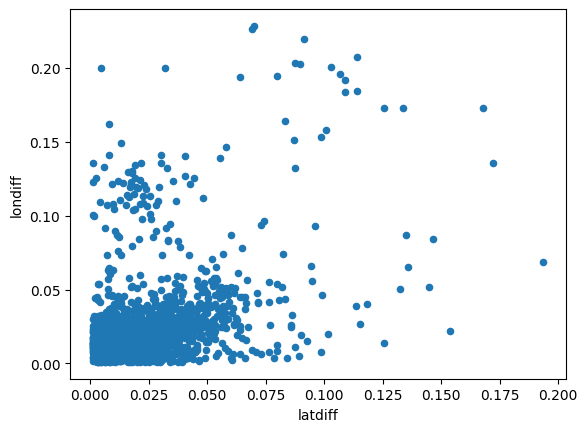

In [16]:
_ = train_df.iloc[:2000].plot.scatter("latdiff", "londiff")
plt.show()



In [17]:
dropped_columns = ["passenger_count", "pickup_datetime"]

train_df = train_df.drop(dropped_columns, axis=1)
test_df = test_df.drop(dropped_columns, axis=1)
testKaggle_clean = testKaggle.drop(dropped_columns + ["key"], axis=1)

print("Done with dropped_columns")
print("train_df columns:", train_df.columns.tolist())
print("testKaggle_clean columns:", testKaggle_clean.columns.tolist())



Done with dropped_columns
train_df columns: ['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'year', 'month', 'day', 'hour', 'weekday', 'night', 'late_night', 'rush_hour', 'latdiff', 'londiff', 'manhattan', 'distance']
testKaggle_clean columns: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'year', 'month', 'day', 'hour', 'weekday', 'night', 'late_night', 'rush_hour', 'latdiff', 'londiff', 'manhattan', 'distance']


In [18]:
train_df.shape



(35477, 17)

In [19]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000,35477.000000
mean,10.875486,-73.976448,40.751755,-73.974968,40.751770,2011.732193,6.257406,15.756744,13.559912,3.058066,0.352736,0.214026,0.199143,0.021613,0.022107,0.043719,0.033622
std,7.657866,0.035460,0.027294,0.032902,0.029911,1.867802,3.458838,8.663392,6.513778,1.953588,0.477828,0.410151,0.399362,0.023222,0.031336,0.048166,0.036696
min,2.500000,-74.220428,40.592197,-74.216774,40.576309,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007,0.002182,0.001545
25%,6.100000,-73.992355,40.737095,-73.991463,40.736118,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007801,0.006958,0.018063,0.013842
50%,8.500000,-73.982155,40.753883,-73.980476,40.754078,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014904,0.013443,0.029785,0.022841
75%,12.500000,-73.968719,40.767986,-73.965607,40.768524,2013.000000,9.000000,23.000000,19.000000,5.000000,1.000000,0.000000,0.000000,0.027824,0.024521,0.052471,0.039582
max,50.000000,-73.137390,41.366138,-73.541473,40.965870,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.727585,0.878448,1.537151,1.097980


In [20]:
test_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000,35346.000000
mean,10.950864,-73.976105,40.751751,-73.974876,40.751865,2011.730606,6.242828,15.670175,13.534374,3.045295,0.349092,0.213857,0.200164,0.021817,0.022340,0.044156,0.033951
std,7.780891,0.036246,0.028187,0.033629,0.030848,1.866600,3.421570,8.709013,6.527105,1.947496,0.476690,0.410033,0.400129,0.023616,0.031997,0.049184,0.037468
min,2.500000,-74.299164,40.574223,-74.295006,40.576077,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007,0.002438,0.001738
25%,6.100000,-73.992233,40.737002,-73.991583,40.735965,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007736,0.007103,0.017944,0.013773
50%,8.500000,-73.982063,40.753649,-73.980507,40.754101,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014917,0.013405,0.029804,0.022912
75%,12.900000,-73.968401,40.768031,-73.965408,40.768406,2013.000000,9.000000,23.000000,19.000000,5.000000,1.000000,0.000000,0.000000,0.028313,0.024641,0.052864,0.039965
max,50.000000,-73.137390,41.548401,-73.137390,41.551392,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.718849,0.868095,1.508053,1.078487


In [21]:
train_df = train_df.sample(frac=1.0, random_state=1).reset_index(drop=True)
train_df, validation_df = train_test_split(train_df, test_size=0.10, random_state=1)



In [22]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000,31929.000000
mean,10.864760,-73.976471,40.751717,-73.975037,40.751801,2011.729838,6.261424,15.737073,13.553885,3.060259,0.352501,0.213693,0.199944,0.021566,0.022035,0.043601,0.033530
std,7.640561,0.035138,0.027076,0.032530,0.029859,1.867088,3.457780,8.669222,6.515443,1.951749,0.477756,0.409919,0.399964,0.022977,0.030791,0.047285,0.036089
min,2.500000,-74.220428,40.592197,-74.216774,40.576309,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007,0.002361,0.001670
25%,6.100000,-73.992386,40.737206,-73.991447,40.736198,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007771,0.006958,0.018009,0.013821
50%,8.500000,-73.982155,40.753876,-73.980522,40.754166,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014839,0.013451,0.029713,0.022819
75%,12.500000,-73.968704,40.767937,-73.965675,40.768536,2013.000000,9.000000,23.000000,19.000000,5.000000,1.000000,0.000000,0.000000,0.027748,0.024521,0.052532,0.039604
max,50.000000,-73.137390,41.366138,-73.541473,40.965870,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.727585,0.849243,1.528824,1.083127


In [23]:
validation_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance
count,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000,3548.000000
mean,10.972005,-73.976204,40.752064,-73.974258,40.751499,2011.753382,6.221251,15.933766,13.614149,3.038331,0.354848,0.217024,0.191939,0.022033,0.022752,0.044786,0.034445
std,7.816600,0.035690,0.029157,0.031842,0.030320,1.874345,3.468628,8.609949,6.499437,1.970231,0.478535,0.412277,0.393881,0.025316,0.035865,0.055467,0.041759
min,2.500000,-74.044029,40.618168,-74.058090,40.592926,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001019,0.001015,0.002182,0.001545
25%,6.100000,-73.991909,40.735653,-73.991596,40.735288,2010.000000,3.000000,9.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.008110,0.006981,0.018531,0.014117
50%,8.500000,-73.982105,40.753990,-73.980206,40.753027,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.015692,0.013336,0.030470,0.022987
75%,12.500000,-73.968826,40.768545,-73.964588,40.768345,2013.000000,9.000000,23.000000,19.000000,5.000000,1.000000,0.000000,0.000000,0.028513,0.024479,0.051969,0.039380
max,49.799999,-73.137390,41.366138,-73.711472,40.910473,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.658703,0.878448,1.537151,1.097980


In [24]:
# --- Score nudge toward target (lower RMSE): log1p target transform for heavy-tailed fare distribution.
# Core architecture/loss/training loop remain identical; only the target scale changes and is inverted for outputs.
train_labels = np.log1p(train_df["fare_amount"].values.astype(np.float32))
validation_labels = np.log1p(validation_df["fare_amount"].values.astype(np.float32))
test_labels = np.log1p(test_df["fare_amount"].values.astype(np.float32))

train_df = train_df.drop(["fare_amount"], axis=1)
validation_df = validation_df.drop(["fare_amount"], axis=1)
test_df = test_df.drop(["fare_amount"], axis=1)

print("Done with Labels")
print(
    "Train X:", train_df.shape, "Val X:", validation_df.shape, "Test X:", test_df.shape
)



Done with Labels
Train X: (31929, 16) Val X: (3548, 16) Test X: (35346, 16)


In [25]:
feature_cols = list(train_df.columns)
validation_df = validation_df[feature_cols]
test_df = test_df[feature_cols]
testKaggle_clean = testKaggle_clean[feature_cols]

scaler = preprocessing.MinMaxScaler()
train_df_scaled = scaler.fit_transform(train_df)
validation_df_scaled = scaler.transform(validation_df)
test_scaled = scaler.transform(test_df)
testKaggle_scaled = scaler.transform(testKaggle_clean)




In [26]:
def rmse_metric(y_true, y_pred):
    return backend.sqrt(backend.mean(backend.square(y_pred - y_true), axis=-1))




In [27]:
model = Sequential()
model.add(
    Dense(
        256,
        activation="linear",
        input_dim=train_df_scaled.shape[1],
        activity_regularizer=regularizers.l1(0.01),
    )
)
model.add(BatchNormalization())
model.add(Dense(128, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(8, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(1))

adam = optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    loss="mean_squared_error", optimizer=adam, metrics=["mae", rmse_metric, "mse"]
)

print("Dataset size: %s" % DATASET_SIZE)
print("Epochs: %s" % EPOCHS)
print("Learning rate: %s" % LEARNING_RATE)
print("Batch size: %s" % BATCH_SIZE)
print("Input dimension: %s" % train_df_scaled.shape[1])
print("Features used: %s" % train_df.columns.tolist())
model.summary()

history = model.fit(
    x=train_df_scaled,
    y=train_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1,
    validation_data=(validation_df_scaled, validation_labels),
    shuffle=True,
)



Dataset size: 80000
Epochs: 50
Learning rate: 0.001
Batch size: 256
Input dimension: 16
Features used: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'year', 'month', 'day', 'hour', 'weekday', 'night', 'late_night', 'rush_hour', 'latdiff', 'londiff', 'manhattan', 'distance']
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               4352      
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormali

2026-01-19 12:34:19.216253: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768826059.216716      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:85:00.0, compute capability: 8.6


Epoch 1/50


I0000 00:00:1768826062.146936      68 service.cc:148] XLA service 0x7f229a49c4a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768826062.146966      68 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-19 12:34:22.152109: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768826062.163735      68 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768826062.213568      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


125/125 [==============================] - 4s 5ms/step - loss: 4.5954 - mae: 2.0443 - rmse_metric: 2.0443 - mse: 4.3838 - val_loss: 4.0355 - val_mae: 1.9099 - val_rmse_metric: 1.9099 - val_mse: 3.8740
Epoch 2/50
125/125 [==============================] - 0s 4ms/step - loss: 1.9290 - mae: 1.2810 - rmse_metric: 1.2810 - mse: 1.7781 - val_loss: 1.0796 - val_mae: 0.8744 - val_rmse_metric: 0.8744 - val_mse: 0.9378
Epoch 3/50
125/125 [==============================] - 0s 4ms/step - loss: 0.4701 - mae: 0.5029 - rmse_metric: 0.5029 - mse: 0.3375 - val_loss: 0.3169 - val_mae: 0.3456 - val_rmse_metric: 0.3456 - val_mse: 0.1938
Epoch 4/50
125/125 [==============================] - 0s 4ms/step - loss: 0.1834 - mae: 0.1967 - rmse_metric: 0.1967 - mse: 0.0699 - val_loss: 0.1934 - val_mae: 0.2329 - val_rmse_metric: 0.2329 - val_mse: 0.0896
Epoch 5/50
125/125 [==============================] - 0s 4ms/step - loss: 0.1504 - mae: 0.1750 - rmse_metric: 0.1750 - mse: 0.0557 - val_loss: 0.1558 - val_mae: 0.

In [28]:
try:
    from IPython.display import SVG

    if KERAS_BACKEND == "tf_keras":
        from tf_keras.utils import model_to_dot
    else:
        from tensorflow.keras.utils import model_to_dot

    SVG(model_to_dot(model).create(prog="dot", format="svg"))
except Exception as e:
    print("Model visualization skipped:", repr(e))



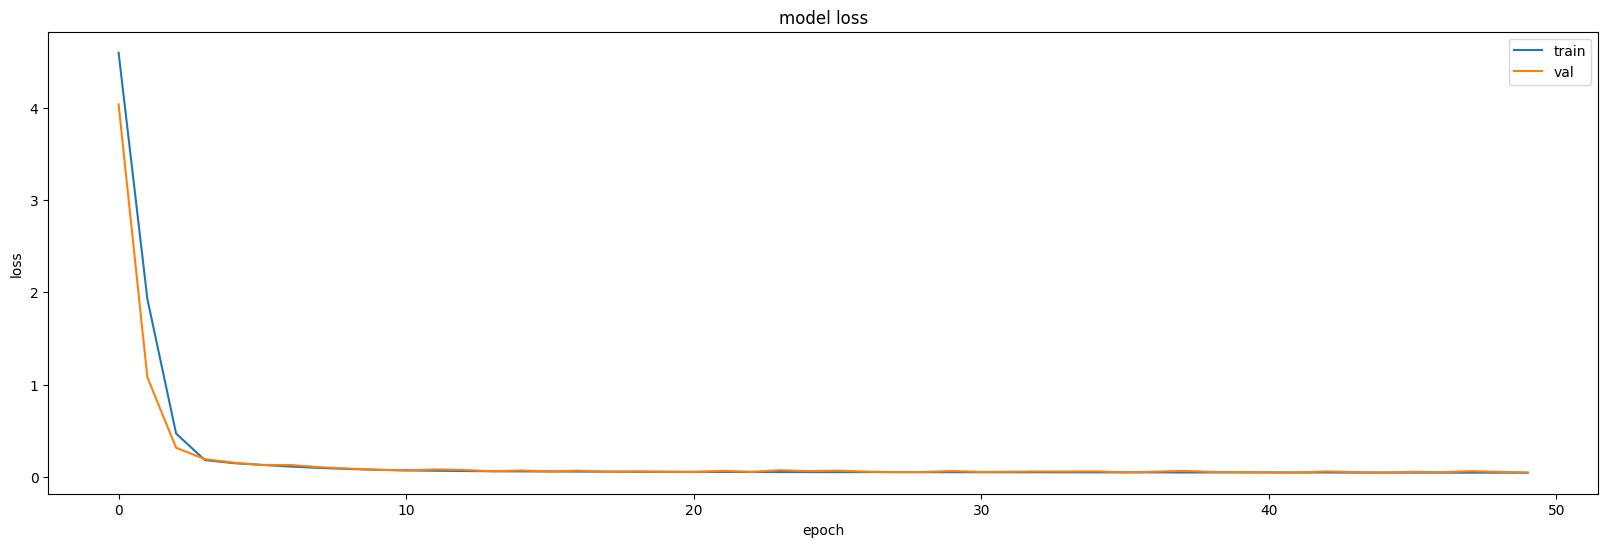

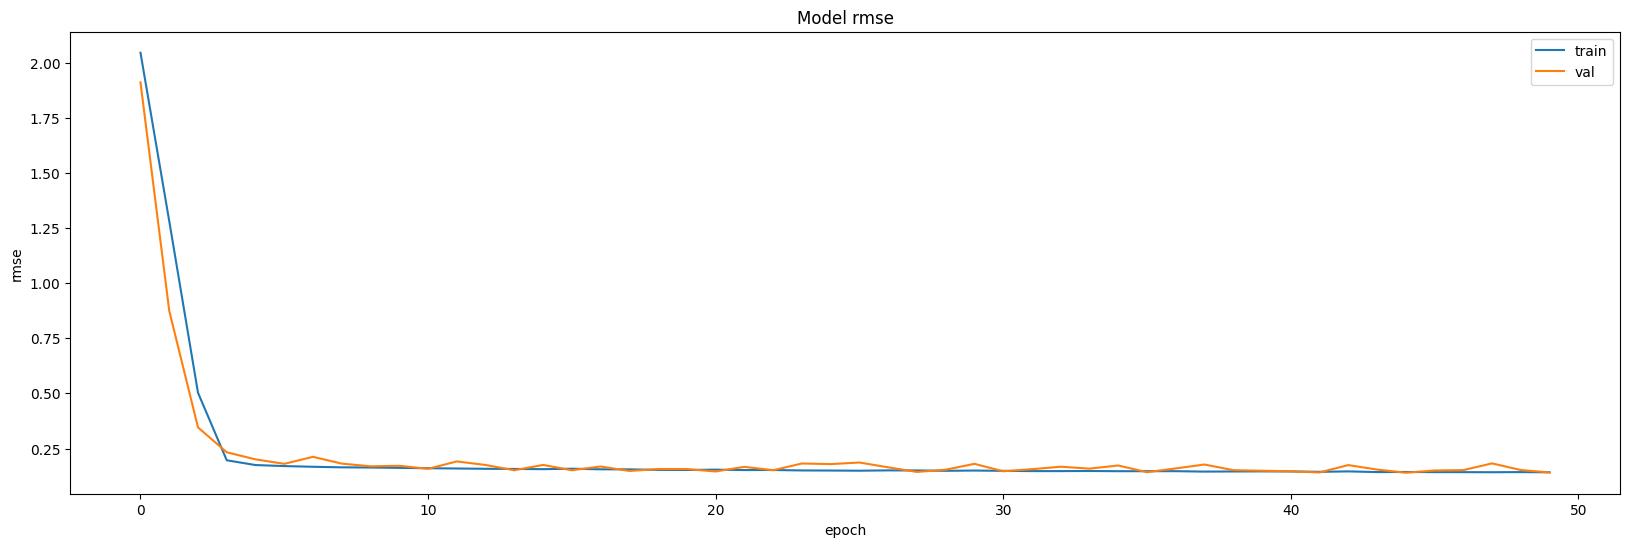

In [29]:
plot_loss_accuracy_rmse(history)



In [30]:
score = model.evaluate(test_scaled, test_labels, verbose=1)
print(score)



1105/1105 [==============================] - 1s 1ms/step - loss: 0.0478 - mae: 0.1422 - rmse_metric: 0.1422 - mse: 0.0419
[0.04781889170408249, 0.14221519231796265, 0.14221519231796265, 0.041877809911966324]


In [31]:
prediction = model.predict(test_scaled, batch_size=128, verbose=1)
predictionKaggle = model.predict(testKaggle_scaled, batch_size=128, verbose=1)




78/78 [==============================] - 0s 818us/step


In [32]:
def rmse_np(predictions, targets):
    predictions = np.asarray(predictions).reshape(-1)
    targets = np.asarray(targets).reshape(-1)
    return np.sqrt(((predictions - targets) ** 2).mean())




In [33]:
Validation_prediction = model.predict(validation_df_scaled, batch_size=128, verbose=1)
rmse_val = rmse_np(Validation_prediction, validation_labels)
print("rmse error is: " + str(rmse_val))



28/28 [==============================] - 0s 848us/step
rmse error is: 0.20574102


In [34]:
rmse_test = rmse_np(prediction, test_labels)
print("rmse error is: " + str(rmse_test))



rmse error is: 0.2046401


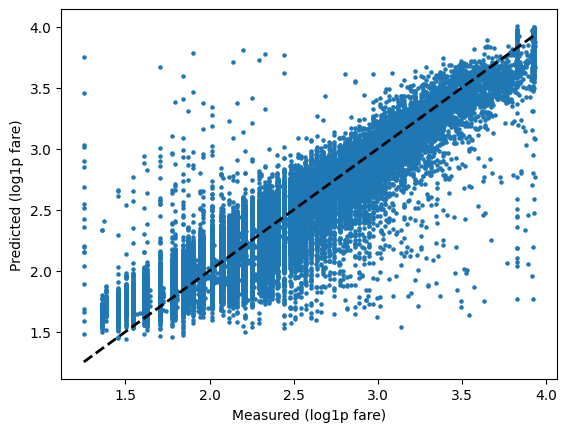

In [35]:
fig, ax = plt.subplots()
ax.scatter(test_labels, prediction, s=5)
ax.plot(
    [test_labels.min(), test_labels.max()],
    [test_labels.min(), test_labels.max()],
    "k--",
    lw=2,
)
ax.set_xlabel("Measured (log1p fare)")
ax.set_ylabel("Predicted (log1p fare)")
plt.show()



In [36]:
# --- Invert log1p transform for Kaggle submission + same robust NaN/inf handling and realistic clipping.
predictionKaggle = predictionKaggle.reshape(-1)
predictionKaggle = np.nan_to_num(
    predictionKaggle, nan=np.log1p(11.35), posinf=np.log1p(50.0), neginf=0.0
)

predictionKaggle = np.expm1(predictionKaggle)
predictionKaggle = np.nan_to_num(predictionKaggle, nan=11.35, posinf=50.0, neginf=0.0)
predictionKaggle = np.clip(predictionKaggle, 0.0, 50.0).astype(np.float32)

output_submission(testKaggle, predictionKaggle, "key", "fare_amount", SUBMISSION_NAME)
print("Submission head:")
print(pd.read_csv(SUBMISSION_NAME).head())
print("Submission shape:", pd.read_csv(SUBMISSION_NAME).shape)

Output complete: submissiontry_water.csv rows: 9914
Submission head:
                             key  fare_amount
0    2010-10-01 21:26:11.0000001     6.269147
1   2013-10-06 01:38:00.00000083    32.421402
2    2012-03-30 19:13:53.0000001     4.922919
3    2012-02-08 02:57:23.0000001    34.479477
4  2013-12-13 22:56:00.000000237    29.393510
Submission shape: (9914, 2)


/tmp/ipykernel_11/3641923452.py:7: RuntimeWarning: overflow encountered in expm1
  predictionKaggle = np.expm1(predictionKaggle)
